In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

### two proportion z-test

In [11]:
df_clean = pd.read_csv(r"C:\Users\Pavitra\Downloads\AB_Testing_Project\notebooks\df_clean")

In [12]:

control = df_clean[df_clean['group']=='control']
treatment = df_clean[df_clean['group']=='treatment']

In [13]:
control_conversion_rate = control['converted'].sum()/len(control)
treatment_conversion_rate = treatment['converted'].sum()/len(treatment)

print(f"control_conversion_rate:{control_conversion_rate:.4f}")
print(f"treatment_conversion_rate:{treatment_conversion_rate:.4f}")


control_conversion_rate:0.1203
treatment_conversion_rate:0.1188


In [14]:
# now is the treatment_conversion_rate - control_conversion_rate  significant ?

In [15]:
# a-two proportion z-test asks : "Is the conversion rate in the treatment group significantly different from the conversion rate in the control group?"

In [16]:
from statsmodels.stats.proportion import proportions_ztest

successes = [treatment['converted'].sum(), control['converted'].sum()]
n_obs = [len(treatment), len(control)]

z_stat, p_value = proportions_ztest(successes, n_obs, alternative='two-sided')
print(f"z-statistic: {z_stat:.4f}, p-value: {p_value:.4f}")

z-statistic: -1.2198, p-value: 0.2226


In [17]:
# results : Since the p-value > 0.05 ,there is not enough statistical evidence to conclude that treatment and control have different conversion rates.

### 95% CI Interval 

In [18]:
from statsmodels.stats.proportion import proportion_confint

ci_control = proportion_confint(control['converted'].sum(), len(control), alpha=0.05)
ci_treatment = proportion_confint(treatment['converted'].sum(), len(treatment), alpha=0.05)
print(f"Control 95% CI: {ci_control}")
print(f"Treatment 95% CI: {ci_treatment}")

Control 95% CI: (0.11862641506332997, 0.12198342554651065)
Treatment 95% CI: (0.11716268858849795, 0.12050084533721662)


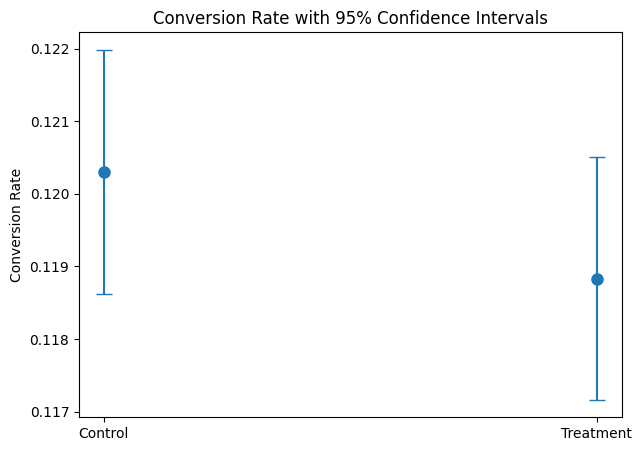

In [19]:
import matplotlib.pyplot as plt
import numpy as np

groups = ['Control', 'Treatment']
rates = [control['converted'].mean(), treatment['converted'].mean()]

errors = np.array([
    [rates[0] - ci_control[0], rates[1] - ci_treatment[0]],
    [ci_control[1] - rates[0], ci_treatment[1] - rates[1]]
])

plt.figure(figsize=(7, 5))

plt.errorbar(
    groups,
    rates,
    yerr=errors,
    fmt='o',
    capsize=6,
    markersize=8
)

plt.ylabel('Conversion Rate')
plt.title('Conversion Rate with 95% Confidence Intervals')
plt.show()

* **Control conversion rate:** ≈ **12.03%**

* **Treatment conversion rate:** ≈ **11.88%**

* Treatment is therefore about **0.15 percentage points lower** than control.

* The vertical bars are the **95% confidence intervals** — they show the uncertainty around each estimated conversion rate.

* The intervals **overlap substantially**, meaning the observed difference is small relative to the uncertainty.

* This visually supports our earlier **two-proportion z-test result**:

  * p-value = **0.2226**
  * Since (p > 0.05), the difference is **not statistically significant**.

### Conclusion

*The observed effect was −0.15pp, far below the +2pp MDE, and the hypothesis test was also not statistically significant.*
**Treatment does not show a statistically significant improvement over control.**
